# IPL Win Probability Predictor

Predicts the probability of the batting team winning a T20 IPL run-chase, based on the match state at any point in the 2nd innings (score, wickets, overs, target).

**Data source:** [Cricsheet](https://cricsheet.org/downloads/) — `ipl_json.zip`, 1,243 IPL matches (2008–present), one JSON file per match, ball-by-ball. CC BY-SA 4.0.

**Scope:** predicts from pre-match-state features only (current score, wickets, overs, target run rate). Does **not** account for player form, injuries, pitch report, or weather — those aren't in this dataset.


In [1]:
import json, glob, os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pickle


## 1. Load the data

Kaggle auto-extracts most zip datasets on upload. This cell handles both cases:
already-extracted `.json` files under `/kaggle/input/...`, or a `.zip` that still
needs unzipping. Edit `DATA_DIR` if your dataset folder name differs.

In [2]:
import zipfile

KAGGLE_INPUT = '/kaggle/input/datasets/harshzala/ipl-json'
DATA_DIR = 'ipl_json'  # working folder where the extracted .json files will live

if not os.path.isdir(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    found_json = False
    if os.path.isdir(KAGGLE_INPUT):
        for root, dirs, files in os.walk(KAGGLE_INPUT):
            for fname in files:
                if fname.endswith('.zip'):
                    with zipfile.ZipFile(os.path.join(root, fname)) as z:
                        z.extractall(DATA_DIR)
                    found_json = True
                elif fname.endswith('.json'):
                    found_json = True
        if found_json and not glob.glob(os.path.join(DATA_DIR, '*.json')):
            # json files were nested in the input dir directly, not zipped
            for root, dirs, files in os.walk(KAGGLE_INPUT):
                for fname in files:
                    if fname.endswith('.json'):
                        import shutil
                        shutil.copy(os.path.join(root, fname), DATA_DIR)

match_files = glob.glob(os.path.join(DATA_DIR, '*.json'))
print(f"Found {len(match_files)} match files")
assert len(match_files) > 1000, "Expected ~1243 IPL match files -- check DATA_DIR / your uploaded dataset"


Found 1243 match files


## 2. Parse matches into ball-level rows

Each Cricsheet file is nested JSON: `info` (teams, venue, outcome) and `innings` ->
`overs` -> `deliveries`. We walk the **second innings only** (the chase) ball by
ball, tracking running totals to build the win-probability features.

Two details that matter for correctness:
- **Target comes from the innings' own `target` field**, not "first innings score + 1".
  This handles Duckworth-Lewis-revised targets correctly (~6 matches in this dataset
  have DL-adjusted targets/overs).
- **Super-over innings are excluded** (flagged `super_over: true` in the JSON) so they
  don't get mistaken for a second innings.
- Matches with no `winner` (tie with no result, abandoned) are skipped — the label
  would be undefined.

In [3]:
def overs_to_balls(overs_val):
    """Cricket over notation: 9.2 means 9 overs + 2 balls = 56 balls, not 9.2*6."""
    whole = int(overs_val)
    frac = round((overs_val - whole) * 10)
    return whole * 6 + frac


def parse_match(path):
    match_id = os.path.splitext(os.path.basename(path))[0]
    m = json.load(open(path))
    info = m['info']
    outcome = info.get('outcome', {})
    winner = outcome.get('winner')
    if winner is None:
        return []  # tie / no result / abandoned -- undefined label, skip

    city = info.get('city') or info.get('venue', 'Unknown')
    teams = info['teams']

    chase_innings = None
    for inn in m['innings']:
        if inn.get('super_over'):
            continue
        if 'target' in inn:
            chase_innings = inn
            break
    if chase_innings is None:
        return []

    batting_team = chase_innings['team']
    bowling_team = [t for t in teams if t != batting_team][0]
    target_runs = chase_innings['target']['runs']
    total_balls = overs_to_balls(chase_innings['target']['overs'])

    rows = []
    cum_runs, cum_wickets, balls_bowled = 0, 0, 0

    for over in chase_innings['overs']:
        for delivery in over['deliveries']:
            extras = delivery.get('extras', {})
            is_legal = not ('wides' in extras or 'noballs' in extras)
            cum_runs += delivery['runs']['total']
            if is_legal:
                balls_bowled += 1
            if 'wickets' in delivery:
                cum_wickets += len(delivery['wickets'])

            balls_left = total_balls - balls_bowled
            if balls_left <= 0:
                continue
            runs_left = target_runs - cum_runs
            wickets_left = 10 - cum_wickets
            crr = (cum_runs * 6 / balls_bowled) if balls_bowled > 0 else 0.0
            rrr = (runs_left * 6 / balls_left) if balls_left > 0 else 0.0

            rows.append({
                'match_id': match_id,
                'batting_team': batting_team,
                'bowling_team': bowling_team,
                'city': city,
                'runs_left': runs_left,
                'balls_left': balls_left,
                'wickets_left': wickets_left,
                'total_runs_x': target_runs,
                'crr': round(crr, 2),
                'rrr': round(rrr, 2),
                'result': 1 if winner == batting_team else 0,
            })
    return rows


all_rows = []
skipped = 0
for f in match_files:
    rows = parse_match(f)
    if not rows:
        skipped += 1
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
print(f"Matches parsed: {len(match_files)}, skipped (no winner / no target): {skipped}")
print(f"Total ball-level rows: {len(df)}")
df.head()


Matches parsed: 1243, skipped (no winner / no target): 25
Total ball-level rows: 139814


,match_id,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,total_runs_x,crr,rrr,result
0,1529298,Delhi Capitals,Punjab Kings,Dharamsala,211,119,10,211,0.0,10.64,1
1,1529298,Delhi Capitals,Punjab Kings,Dharamsala,207,118,10,211,12.0,10.53,1
2,1529298,Delhi Capitals,Punjab Kings,Dharamsala,206,117,10,211,10.0,10.56,1
3,1529298,Delhi Capitals,Punjab Kings,Dharamsala,205,116,10,211,9.0,10.60,1
4,1529298,Delhi Capitals,Punjab Kings,Dharamsala,205,115,10,211,7.2,10.70,1


## 3. Quick sanity checks

In [4]:
print(df['result'].value_counts(normalize=True))
print()
pd.concat([df['batting_team'], df['bowling_team']]).value_counts().head(10)


result
1    0.526829
0    0.473171
Name: proportion, dtype: float64



Mumbai Indians                 33291
Chennai Super Kings            30755
Kolkata Knight Riders          30381
Rajasthan Royals               28213
Royal Challengers Bangalore    26772
Sunrisers Hyderabad            23667
Kings XI Punjab                21221
Delhi Daredevils               17631
Delhi Capitals                 13347
Punjab Kings                    9876
Name: count, dtype: int64

## 4. Train / test split — grouped by match

Rows from the same match are near-duplicates of each other (score ticks up by a few
runs each ball). A plain random row split leaks match context between train and test
and inflates accuracy to a meaningless ~99%. Splitting by `match_id` so an entire
match lands on only one side of the split gives an honest number.

In [5]:
X = df.drop(columns=['result', 'match_id'])
y = df['result']
groups = df['match_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train matches: {groups.iloc[train_idx].nunique()}, rows: {len(X_train)}")
print(f"Test matches:  {groups.iloc[test_idx].nunique()}, rows: {len(X_test)}")


Train matches: 974, rows: 111438
Test matches:  244, rows: 28376


## 5. Model

`batting_team`, `bowling_team`, `city` are one-hot encoded; the numeric features
pass through unchanged. Two models for comparison — Logistic Regression as a simple
baseline, Random Forest as the main model.

In [6]:
cat_cols = ['batting_team', 'bowling_team', 'city']
preprocessor = ColumnTransformer(
    transformers=[('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)],
    remainder='passthrough'
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=1),
}

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessing', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (pipe, y_pred, acc)
    print(f"{name}: accuracy = {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: accuracy = 0.7598
Random Forest: accuracy = 0.7675


## 6. Evaluate the Random Forest model in detail

              precision    recall  f1-score   support

           0       0.76      0.78      0.77     14038
           1       0.78      0.76      0.77     14338

    accuracy                           0.77     28376
   macro avg       0.77      0.77      0.77     28376
weighted avg       0.77      0.77      0.77     28376



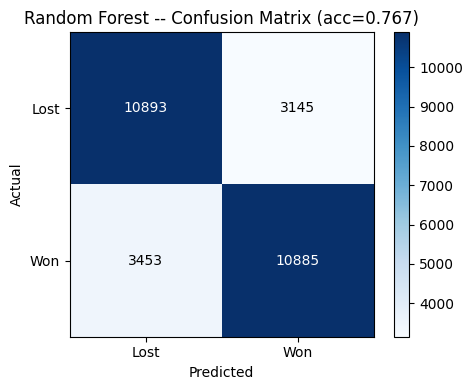

In [7]:
best_pipe, best_pred, best_acc = results['Random Forest']

print(classification_report(y_test, best_pred))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Lost', 'Won']); ax.set_yticklabels(['Lost', 'Won'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Random Forest -- Confusion Matrix (acc={best_acc:.3f})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 7. Save the model

`pipe.pkl` bundles the preprocessing (one-hot encoder) and the trained Random
Forest together, so it can be loaded directly in the dashboard/app without
repeating any preprocessing code.

In [8]:
with open('pipe.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)
print("Saved pipe.pkl")


Saved pipe.pkl


## 8. Try a prediction

Example: predict on a current match state (edit the values below to try others).

In [9]:
sample = pd.DataFrame([{
    'batting_team': 'Chennai Super Kings',
    'bowling_team': 'Mumbai Indians',
    'city': 'Chennai',
    'runs_left': 42,
    'balls_left': 36,
    'wickets_left': 6,
    'total_runs_x': 178,
    'crr': 8.6,
    'rrr': 7.0,
}])

prob = best_pipe.predict_proba(sample)[0]
print(f"{sample['batting_team'][0]} win probability: {prob[1]*100:.1f}%")
print(f"{sample['bowling_team'][0]} win probability: {prob[0]*100:.1f}%")


Chennai Super Kings win probability: 96.5%
Mumbai Indians win probability: 3.5%
